In [1]:
import pandas as pd
import numpy as np
import requests
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from understatapi import UnderstatClient
from IPython.display import display, Markdown

In [2]:
def train_model(mode="short"):
    print("Loading player data...")
    base_url = "https://fantasy.premierleague.com/api/"
    bootstrap = requests.get(base_url + "bootstrap-static/").json()
    df = pd.DataFrame(bootstrap["elements"])
    df = df[(df["minutes"] > 0) & (df["team"] > 0)].copy()
    df["web_name"] = df["web_name"].astype(str)

    print("Adding team form...")
    teams = pd.DataFrame(bootstrap["teams"])
    # Team name map for merging later
    team_name_map = dict(zip(teams["id"], teams["name"]))
    df["team_name"] = df["team"].map(team_name_map)
    team_form_map = dict(zip(teams["id"], teams["form"]))
    team_name_map = dict(zip(teams["id"], teams["name"]))
    df["team_form"] = df["team"].map(team_form_map)
    df["team_name"] = df["team"].map(team_name_map)
    df["team_form"] = pd.to_numeric(df["team_form"], errors="coerce").fillna(0)

    print("Scoring fixture difficulty...")
    fixtures = pd.DataFrame(requests.get(base_url + "fixtures/").json())
    current_event = fixtures["event"].dropna().min()
    upcoming = fixtures[(fixtures["event"] >= current_event) & (fixtures["event"] < current_event + 3)]

    difficulty_score = {}
    for team_id in df["team"].unique():
        team_fixtures = upcoming[(upcoming["team_h"] == team_id) | (upcoming["team_a"] == team_id)]
        score = 0
        for _, row in team_fixtures.iterrows():
            is_home = row["team_h"] == team_id
            score += row["team_h_difficulty"] if is_home else row["team_a_difficulty"]
        difficulty_score[team_id] = score / max(1, len(team_fixtures))
    df["fixture_difficulty"] = df["team"].map(difficulty_score)

    if mode == "short":
        target = "ep_next"
        features = [
            "form", "ict_index", "influence", "creativity", "threat",
            "minutes", "goals_scored", "assists", "clean_sheets",
            "yellow_cards", "red_cards", "element_type",
            "team_form", "fixture_difficulty"
        ]
        df[target] = pd.to_numeric(df.get(target, None), errors="coerce")

    elif mode == "long":
        print("Refactoring long-term target to future points...")
        df["ep_this"] = pd.to_numeric(df.get("ep_this", None), errors="coerce")
        df["ep_next"] = pd.to_numeric(df.get("ep_next", None), errors="coerce")
        df = df.dropna(subset=["ep_this", "ep_next"])

        remaining_gws = 38 - 32
        df["future_points"] = (df["ep_this"] + df["ep_next"]) / 2 * remaining_gws
        target = "future_points"

        # Add xG/xGA via Understat API
        print("Fetching team xG/xGA...")

        from understatapi import UnderstatClient
        understat = UnderstatClient()
        team_data = understat.league("EPL").get_team_data(season="2024")
        
        #print("team_data keys:", team_data.keys())
        #sample_key = next(iter(team_data))
        #print("Sample entry:", team_data[sample_key])

        # Extract final season stats for xG and xGA
        xg_list = []
        for team_id, team_info in team_data.items():
            team_name = team_info["title"]
            history = team_info.get("history", [])
            if history:
                total_xG = sum(float(game.get("xG", 0)) for game in history)
                total_xGA = sum(float(game.get("xGA", 0)) for game in history)
                xg_list.append({
                    "team_name": team_name,
                    "xG": total_xG,
                    "xGA": total_xGA
                })

        team_df = pd.DataFrame(xg_list)
        
        # Merge xG/xGA data into FPL dataset
        df = df.merge(team_df, on="team_name", how="left")
        df["xG"] = pd.to_numeric(df["xG"], errors="coerce").fillna(0)
        df["xGA"] = pd.to_numeric(df["xGA"], errors="coerce").fillna(0)

        features = [
            "goals_scored", "assists", "ict_index", "influence", "creativity",
            "minutes", "team_form", "fixture_difficulty", "xG", "xGA"
        ]

    else:
        raise ValueError("Mode must be 'short' or 'long'")

    df[features + [target]] = df[features + [target]].apply(pd.to_numeric, errors="coerce")
    df = df.dropna(subset=features + [target])

    X = df[features]
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Mode: {mode.upper()} | Target = {target}")
    print("Target sample values:", list(y_test[:5]))
    print("Predicted sample values:", list(y_pred[:5]))
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
    print("R² Score:", r2_score(y_test, y_pred))
    print(f"Training on {len(df)} valid player rows.")

    df["predicted_points"] = model.predict(X)
    model_path = f"fpl_model_{mode}.pkl"
    joblib.dump(model, model_path)
    print(f"Model saved to {model_path}")

    plt.figure(figsize=(10, 5))
    sns.barplot(x=model.feature_importances_, y=features)
    plt.title(f"Feature Importance ({mode.capitalize()}-term)")
    plt.tight_layout()
    plt.show()

    return model, df


Loading player data...
Adding team form...
Scoring fixture difficulty...
Mode: SHORT | Target = ep_next
Target sample values: [1.5, 3.3, 0.0, 1.0, 0.0]
Predicted sample values: [np.float64(1.7530000000000001), np.float64(3.542000000000002), np.float64(0.1429999999999999), np.float64(1.5119999999999998), np.float64(-0.242)]
Mean Absolute Error: 0.5086396396396398
R² Score: 0.8607594932713489
Training on 555 valid player rows.
Model saved to fpl_model_short.pkl


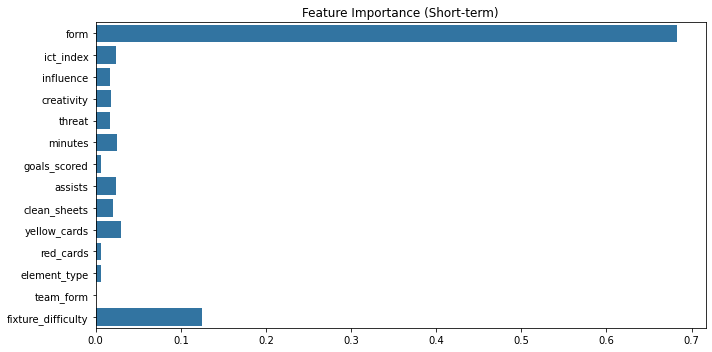

Loading player data...
Adding team form...
Scoring fixture difficulty...
Refactoring long-term target to future points...
Fetching team xG/xGA...
Mode: LONG | Target = future_points
Target sample values: [6.0, 21.299999999999997, 0.0, 7.5, 0.0]
Predicted sample values: [np.float64(21.114000000000015), np.float64(12.663), np.float64(14.334000000000009), np.float64(5.85), np.float64(2.453999999999999)]
Mean Absolute Error: 7.422810810810812
R² Score: 0.2589548431023193
Training on 555 valid player rows.
Model saved to fpl_model_long.pkl


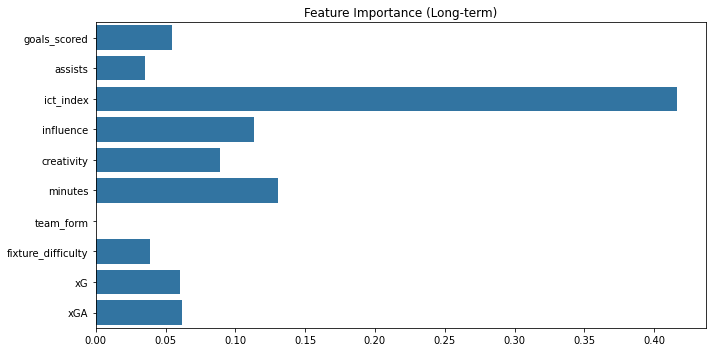

In [3]:
short_model, short_df = train_model(mode="short")
long_model, long_df = train_model(mode="long")


In [4]:
# Short-term
display(Markdown("### Top 15 Players (Short-Term Prediction)"))
display(
    short_df[["web_name", "predicted_points", "form", "minutes"]]
    .sort_values(by="predicted_points", ascending=False)
    .head(15)
)

# Long-term
long_df["total_points"] = pd.to_numeric(long_df["total_points"], errors="coerce").fillna(0)
long_df["total_predicted_points"] = long_df["total_points"] + long_df["predicted_points"]

display(Markdown("### Top 15 Players (Long-Term Projection + Current Total Points)"))
display(
    long_df[["web_name", "total_points", "predicted_points", "total_predicted_points"]]
    .sort_values(by="total_predicted_points", ascending=False)
    .head(15)
)

### Top 15 Players (Short-Term Prediction)

,web_name,predicted_points,form,minutes
459,Luis Díaz,7.264,6.8,2145
571,J.Murphy,6.627,8.4,2014
134,Mbeumo,6.579,7.8,2965
145,Wissa,6.370,6.8,2471
470,Virgil,6.309,6.2,2970
343,Iwobi,6.167,6.0,2637
586,Tonali,6.116,6.0,2175
754,Aït-Nouri,6.106,7.2,2702
562,Barnes,6.003,9.0,1328
584,Schär,5.922,6.4,2493


### Top 15 Players (Long-Term Projection + Current Total Points)

,web_name,total_points,predicted_points,total_predicted_points
318,M.Salah,320,31.752,351.752
90,Mbeumo,210,26.856,236.856
395,Isak,192,30.003,222.003
152,Palmer,194,24.177,218.177
427,Wood,184,21.897,205.897
317,Luis Díaz,165,37.866,202.866
338,Haaland,171,27.477,198.477
44,Watkins,168,25.935,193.935
99,Wissa,159,29.595,188.595
531,Cunha,158,26.823,184.823
